# Project 3


## 1. Recursive Definition

#### Context:
We have a knapsack of capacity weight C (a positive integer) and n types of objects.
Each object of the ith type has weight wi and profit pi (all wi and all p i are positive
integers, i = 0, 1, …, n-1). There are unlimited supplies of each type of objects. Find
the largest total profit of any set of the objects that fits in the knapsack.

Let P(C) be the maximum profit that can be made by packing objects into the knapsack
of capacity C.

P(C) = 

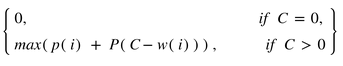

- p(i) is the profit of the item on the ith iteration
- w(i) is the weight of the item on the ith iteration
- Assumption: Unlimited items of each type of objects.

In [10]:
def print_dp_table(dp, capacity, items):
    n = len(items)

    # choose a column width for nice alignment
    col_w = 5

    # header: "C\i" then item indices 0..n
    header = ["C\\i"] + [str(i) for i in range(n + 1)]
    print("\nDP table (rows: capacity 0..C, cols: items 0..n)")
    print("".join(f"{h:>{col_w}}" for h in header))

    # each row = one capacity value, c = 0..C
    for c in range(capacity + 1):
        row_values = [str(c)] + [str(dp[i][c]) for i in range(n + 1)]
        print("".join(f"{val:>{col_w}}" for val in row_values))

In [11]:
import math

# return: max profit
def P(capacity:int, items: None) -> int:
    
    if items is None:
        return 0
    
    n = len(items)

    #create DP table
    dp = []
    for row in range(n+1):
        row_items = []
        for column in range(capacity + 1):
            row_items.append(0)
        dp.append(row_items)


    #build table bottom-up approach
    #row is number of items considered
    #col is current capacity
    
    for row in range(1, n+1):
        i_weight = items[row - 1][0]
        i_profit = items[row - 1][1]
        
        for column in range(1, capacity+1):
            if i_weight <= column:
                include = i_profit + dp[row][column - i_weight]
                exclude = dp[row - 1][column]
                dp[row][column] = max(include,exclude)
            else:
                dp[row][column] = dp[row-1][column]
    
    print_dp_table(dp, capacity, items)
    
    return dp[n][capacity]

In [12]:
if __name__ == "__main__":

    #Question 4a
    weights = [4,6,8]
    profits = [7,6,9]
    C = 14

    print("Weights =", weights)
    print("Profits =", profits)
    print("Capacity: ", C)
    knapsack = list(zip(weights, profits))

    # find max profit for bag of size C
    max_profit = P(C, knapsack)
    print("Maximum profit is: ", max_profit)

Weights = [4, 6, 8]
Profits = [7, 6, 9]
Capacity:  14

DP table (rows: capacity 0..C, cols: items 0..n)
  C\i    0    1    2    3
    0    0    0    0    0
    1    0    0    0    0
    2    0    0    0    0
    3    0    0    0    0
    4    0    7    7    7
    5    0    7    7    7
    6    0    7    7    7
    7    0    7    7    7
    8    0   14   14   14
    9    0   14   14   14
   10    0   14   14   14
   11    0   14   14   14
   12    0   21   21   21
   13    0   21   21   21
   14    0   21   21   21
Maximum profit is:  21


In [13]:
if __name__ == "__main__":

    #Question 4b
    weights = [5,6,8]
    profits = [7,6,9]
    C = 14

    print("Weights =", weights)
    print("Profits =", profits)
    print("Capacity: ", C)
    knapsack = list(zip(weights, profits))

    # find max profit for bag of size C = 14 
    max_profit = P(14, knapsack)
    print("Maximum profit is: ", max_profit)

Weights = [5, 6, 8]
Profits = [7, 6, 9]
Capacity:  14

DP table (rows: capacity 0..C, cols: items 0..n)
  C\i    0    1    2    3
    0    0    0    0    0
    1    0    0    0    0
    2    0    0    0    0
    3    0    0    0    0
    4    0    0    0    0
    5    0    7    7    7
    6    0    7    7    7
    7    0    7    7    7
    8    0    7    7    9
    9    0    7    7    9
   10    0   14   14   14
   11    0   14   14   14
   12    0   14   14   14
   13    0   14   14   16
   14    0   14   14   16
Maximum profit is:  16
